# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading Data

In [55]:
df = pd.read_csv(r'C:\Users\omar\Project\Predict_Calorie_Expenditure.csv')

In [13]:
df.isna().sum()

Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [42]:
df.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


# EDA

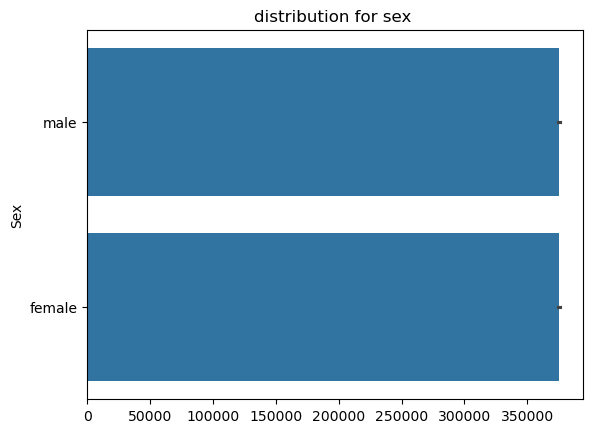

In [6]:
sns.barplot(df['Sex'])
plt.title("distribution for sex ")
plt.show()

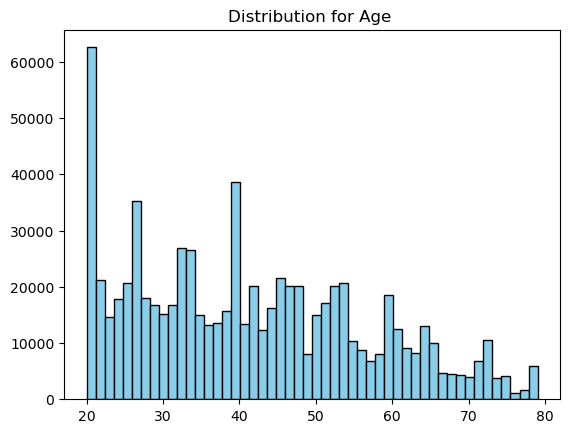

In [51]:
plt.hist(df['Age'],bins=50,color='skyblue', edgecolor='black')
plt.title("Distribution for Age ")
plt.show()

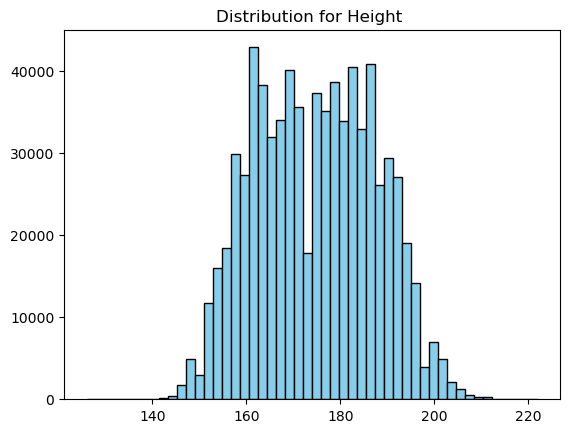

In [52]:
plt.hist(df['Height'],bins=50,color='skyblue', edgecolor='black')
plt.title("Distribution for Height ")
plt.show()

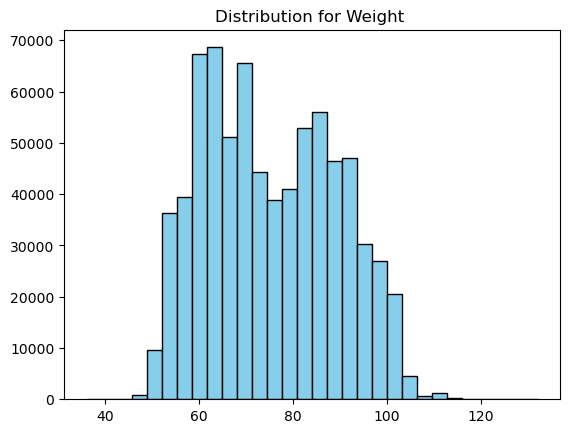

In [9]:
plt.hist(df['Weight'],bins=30,color='skyblue', edgecolor='black')
plt.title("Distribution for Weight ")
plt.show()

<Axes: xlabel='Duration', ylabel='Heart_Rate'>

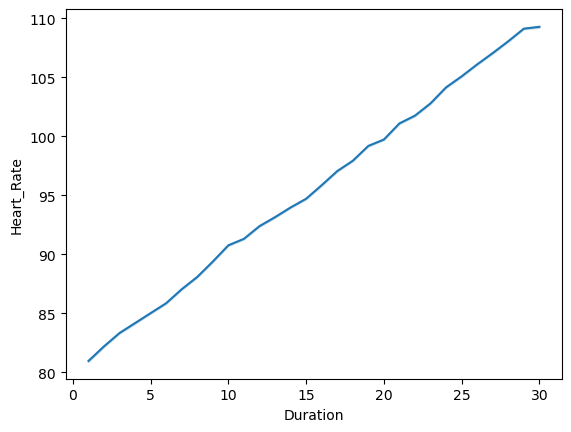

In [31]:
sns.lineplot(x=df['Duration'], y=df['Heart_Rate'])


<Axes: xlabel='Duration', ylabel='Body_Temp'>

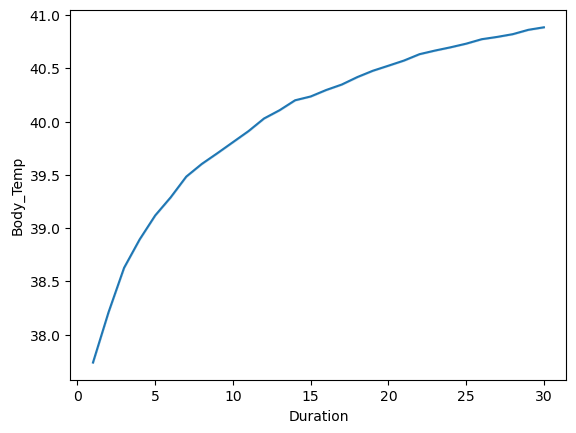

In [30]:
sns.lineplot(x=df['Duration'], y=df['Body_Temp'])

<Axes: xlabel='Duration', ylabel='Calories'>

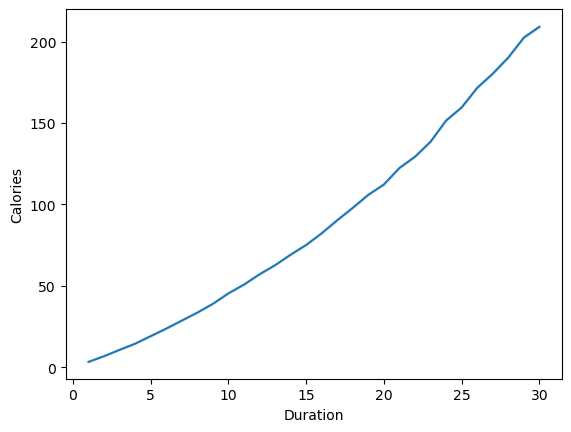

In [29]:
sns.lineplot(x=df['Duration'], y=df['Calories'])

<Axes: xlabel='Heart_Rate', ylabel='Calories'>

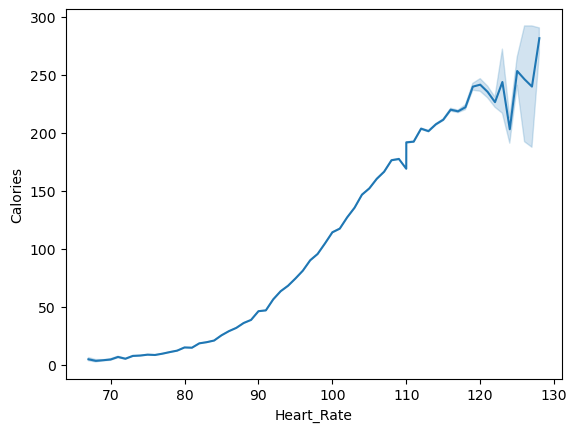

In [32]:
sns.lineplot(x=df['Heart_Rate'], y=df['Calories'])

<Axes: xlabel='Body_Temp', ylabel='Calories'>

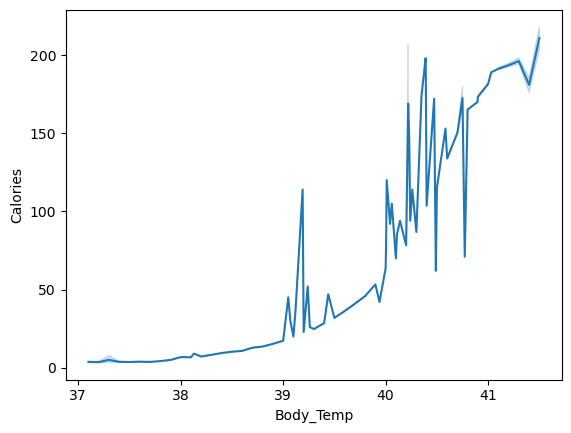

In [33]:
sns.lineplot(x=df['Body_Temp'], y=df['Calories'])

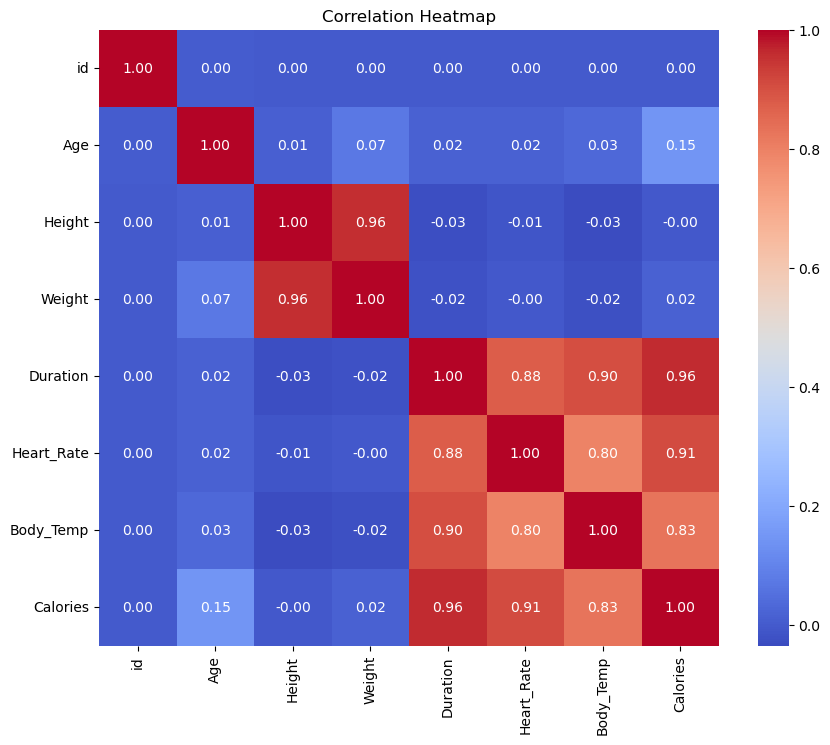

In [ ]:
# Correlation Heatmap if there are 4 or more numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_df = df[numeric_cols]

if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10,8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.savefig('correlation_heatmap.png')
    plt.show()

# Preprocessing


In [63]:
df.drop('id',inplace=True,axis=1)

In [64]:
df.duplicated().sum()

2841

In [65]:
df.drop_duplicates(inplace=True)

In [66]:
x = df.drop('Calories',axis=1)
y = df['Calories']

In [17]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 747159 entries, 0 to 749999
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         747159 non-null  object 
 1   Age         747159 non-null  int64  
 2   Height      747159 non-null  float64
 3   Weight      747159 non-null  float64
 4   Duration    747159 non-null  float64
 5   Heart_Rate  747159 non-null  float64
 6   Body_Temp   747159 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 45.6+ MB


In [18]:
x.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,male,36,189.0,82.0,26.0,101.0,41.0
1,female,64,163.0,60.0,8.0,85.0,39.7
2,female,51,161.0,64.0,7.0,84.0,39.8
3,male,20,192.0,90.0,25.0,105.0,40.7
4,female,38,166.0,61.0,25.0,102.0,40.6


In [19]:
cat = []
quant = []
for i in x.columns:
    if x[i].dtype == 'object':
        cat.append(i)
    elif len(x[i].unique()) > 10:
        quant.append(i)
    else:
        quant.append(i)
print(cat)
print(quant)

['Sex']
['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']


In [67]:
x['Sex'] = x['Sex'].map({'male':1,'female':0})

<Axes: >

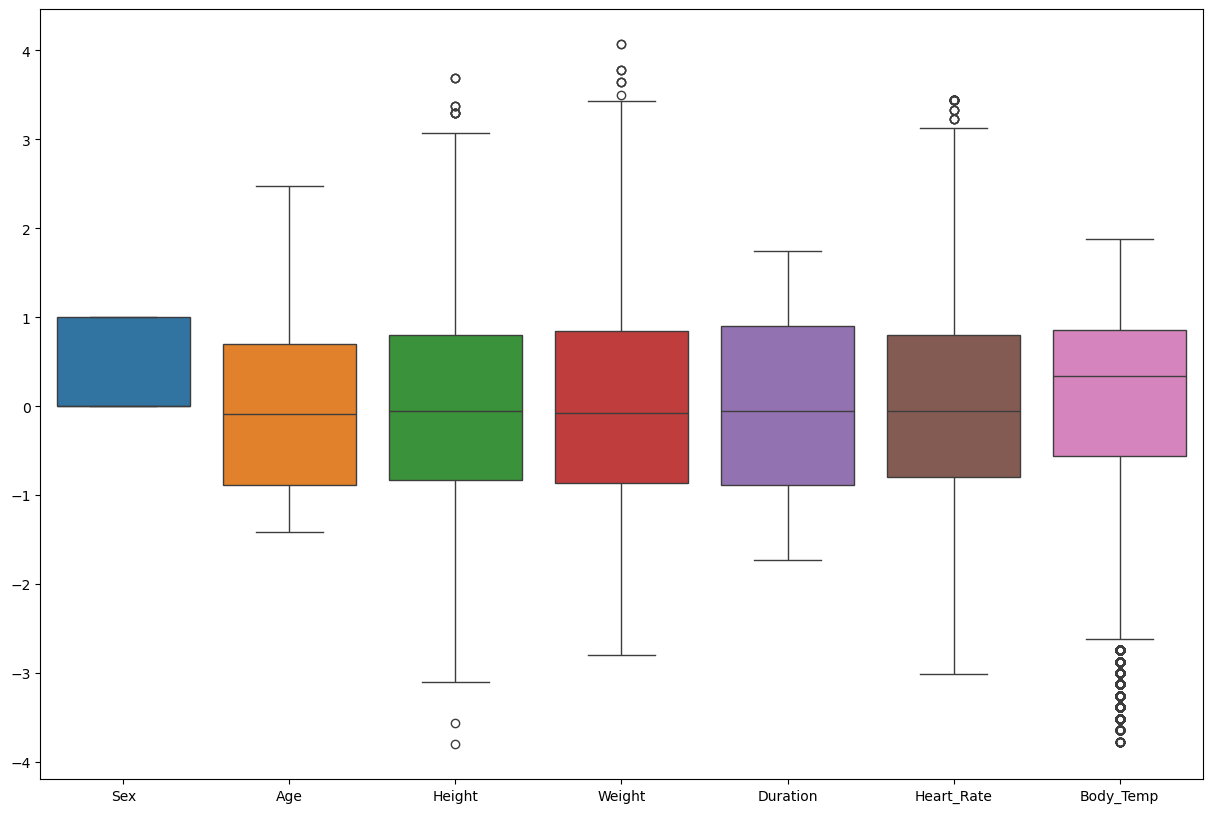

In [22]:
# Outliers
plt.figure(figsize=(15,10))
sns.boxplot(x)

In [47]:
df['Body_Temp'].describe()

count    750000.000000
mean         40.036253
std           0.779875
min          37.100000
25%          39.600000
50%          40.300000
75%          40.700000
max          41.500000
Name: Body_Temp, dtype: float64

In [49]:
for i in quant:
    q1 = x[i].quantile(0.25)
    q3 = x[i].quantile(0.75)
    iqr = q3-q1
    upper = q3+1.5*iqr
    lower = q1-1.5*iqr
    x = x[(x[i] >= lower) & (x[i] <= upper)]

<Axes: >

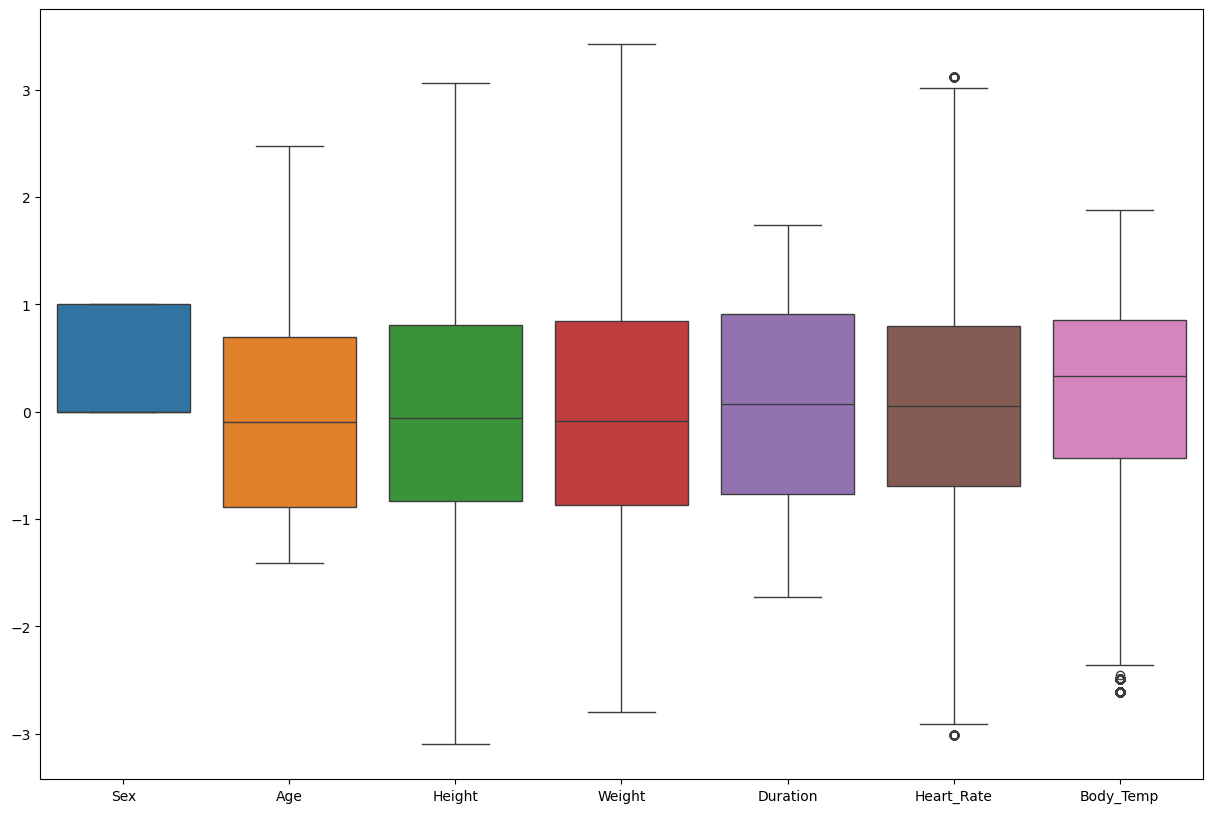

In [50]:
plt.figure(figsize=(15,10))
sns.boxplot(x)

# Splitting data and train the model

In [68]:
from sklearn.model_selection import train_test_split

y = y.loc[x.index]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

### Linear Regression

In [53]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)
lr.score(x_train,y_train)

0.9683556928301216

In [54]:
lr.score(x_test,y_test)

0.968303405502554

### XGBoost

In [ ]:
from xgboost import XGBRegressor
xgb = XGBRegressor()
xgb.fit(x_train,y_train)
xgb.score(x_train,y_train)

0.9967459540040675

In [61]:
xgb.score(x_test,y_test)

0.9962927017763731

## For Deployment

In [70]:
import pickle
filename = 'model.sav'
pickle.dump(xgb,open(filename,'wb'))